In [ ]:
# Fraud Transactions ( Betrug Transaktionen  )

In [ ]:
# Best performing model is XGBClassifier:  It refers to Gradient Boosted decision trees.
# In this algorithm, decision trees are created in sequential form and weights are assigned to
# all the independent variables which are then fed into the decision tree which predicts results.

In [ ]:
# step - tells about the unit of time
# type - type of transaction done
# amount - the total amount of transaction
# nameOrg - account that starts the transaction
# oldbalanceOrg - Balance of the account of sender before transaction
# newbalanceOrg - Balance of the account of sender after transaction
# nameDest - account that receives the transaction
# oldbalanceDest - Balance of the account of receiver before transaction
# newbalanceDest - Balance of the account of receiver after transaction
# isFraud - The value to be predicted i.e. 0 or 1

In [ ]:
pip install gensim

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from pprint import pprint as pp
import csv
from pathlib import Path
import seaborn as sns
from itertools import product
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score, classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.metrics import homogeneity_score, silhouette_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import MiniBatchKMeans, DBSCAN

import gensim
from gensim import corpora
from gensim.models.ldamodel import LdaModel
from gensim.corpora.dictionary import Dictionary

from typing import List, Tuple
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

%matplotlib inline

In [3]:
# Load Data 1
data1 = pd.read_csv('data1.csv') # new_data.csv
data1.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
# Load Data 2
# data2 = pd.read_csv('data2.csv') # creditcard.csv
# data2.head()

In [ ]:
# Data1

In [4]:
data=data1
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287568 entries, 0 to 287567
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            287568 non-null  int64  
 1   type            287568 non-null  object 
 2   amount          287568 non-null  float64
 3   nameOrig        287568 non-null  object 
 4   oldbalanceOrg   287568 non-null  float64
 5   newbalanceOrig  287568 non-null  float64
 6   nameDest        287567 non-null  object 
 7   oldbalanceDest  287567 non-null  float64
 8   newbalanceDest  287567 non-null  float64
 9   isFraud         287567 non-null  float64
 10  isFlaggedFraud  287567 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 24.1+ MB


In [5]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,287568.000000,2.875680e+05,2.875680e+05,2.875680e+05,2.875670e+05,2.875670e+05,287567.000000,287567.0
mean,11.287629,1.768339e+05,8.828152e+05,9.015769e+05,9.722454e+05,1.196402e+06,0.000616,0.0
std,2.588137,3.046953e+05,2.822913e+06,2.860450e+06,2.365799e+06,2.597810e+06,0.024802,0.0
min,1.000000,3.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,9.000000,1.267318e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,11.000000,7.694082e+04,1.875400e+04,0.000000e+00,8.158400e+04,1.841253e+05,0.000000,0.0
75%,13.000000,2.314142e+05,1.846476e+05,2.226594e+05,8.468607e+05,1.237963e+06,0.000000,0.0
max,15.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.133844e+07,4.138365e+07,1.000000,0.0


In [6]:
obj = (data.dtypes == 'object')
object_cols = list(obj[obj].index)
print("Categorical variables:", len(object_cols))

int_ = (data.dtypes == 'int')
num_cols = list(int_[int_].index)
print("Integer variables:", len(num_cols))

fl = (data.dtypes == 'float')
fl_cols = list(fl[fl].index)
print("Float variables:", len(fl_cols))

Categorical variables: 3
Integer variables: 1
Float variables: 7


<Axes: xlabel='type', ylabel='count'>

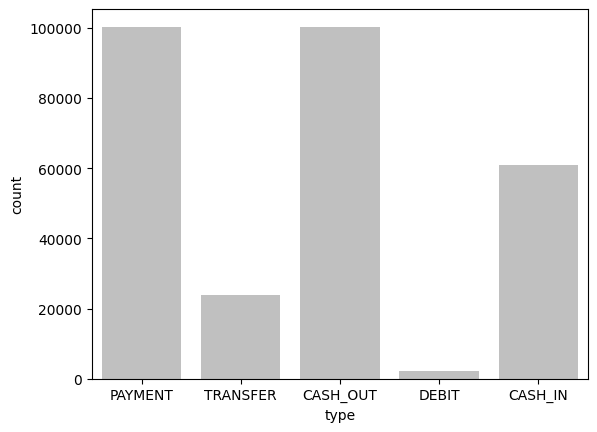

In [7]:
sns.countplot(x='type', data=data, color = "silver")

<Axes: xlabel='type', ylabel='amount'>

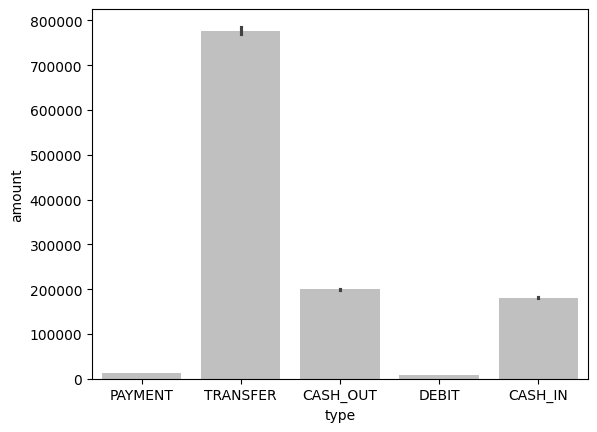

In [8]:
sns.barplot(x='type', y='amount', data=data, color = "silver")

In [9]:
data['isFraud'].value_counts()

,count
isFraud,
0.0,287390
1.0,177


<Axes: xlabel='step', ylabel='Density'>

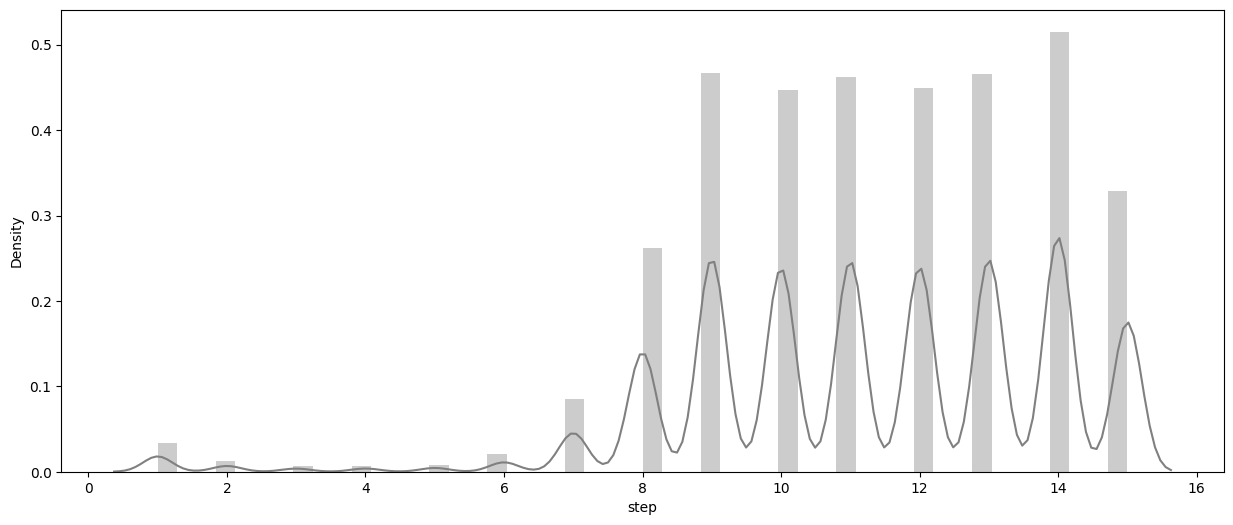

In [10]:
plt.figure(figsize=(15, 6))
sns.distplot(data['step'], bins=50, color="Grey")

<Axes: >

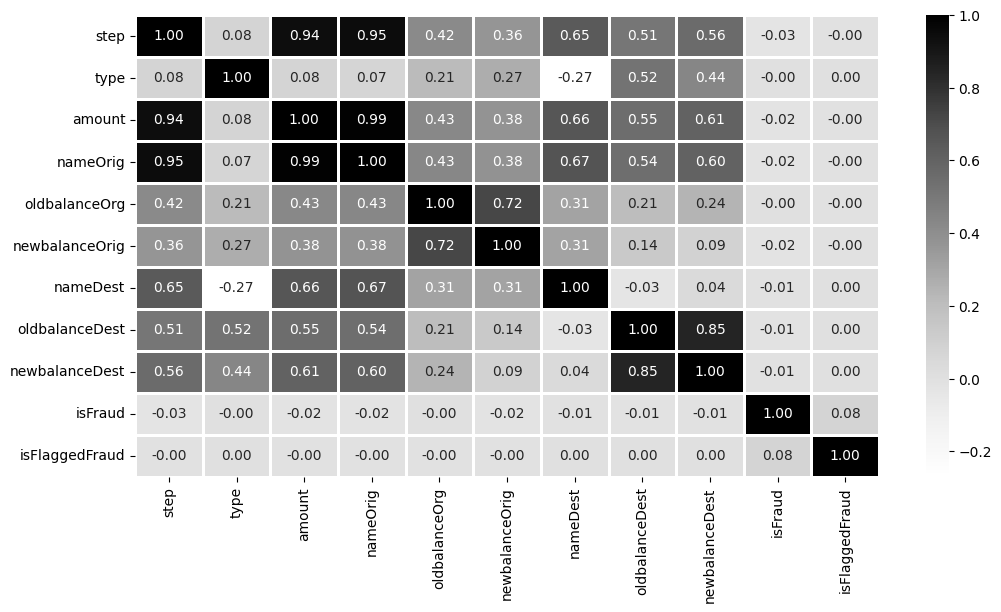

In [11]:
plt.figure(figsize=(12, 6))
sns.heatmap(data.apply(lambda x: pd.factorize(x)[0]).corr(),
			cmap='Greys',
			fmt='.2f',
			linewidths=2,
			annot=True)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287568 entries, 0 to 287567
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            287568 non-null  int64  
 1   type            287568 non-null  object 
 2   amount          287568 non-null  float64
 3   nameOrig        287568 non-null  object 
 4   oldbalanceOrg   287568 non-null  float64
 5   newbalanceOrig  287568 non-null  float64
 6   nameDest        287567 non-null  object 
 7   oldbalanceDest  287567 non-null  float64
 8   newbalanceDest  287567 non-null  float64
 9   isFraud         287567 non-null  float64
 10  isFlaggedFraud  287567 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 24.1+ MB


In [13]:
def missing_zero_values_table(df):
        zero_val = (df == 0.00).astype(int).sum(axis=0)
        mis_val = df.isnull().sum()
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        mz_table = pd.concat([zero_val, mis_val, mis_val_percent], axis=1)
        mz_table = mz_table.rename(
        columns = {0 : 'Zero Values', 1 : 'Missing Values', 2 : '% of Total Values'})
        mz_table['Total Zero Missing Values'] = mz_table['Zero Values'] + mz_table['Missing Values']
        mz_table['% Total Zero Missing Values'] = 100 * mz_table['Total Zero Missing Values'] / len(df)
        mz_table['Data Type'] = df.dtypes
        mz_table = mz_table[
            mz_table.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns and " + str(df.shape[0]) + " Rows.\n"
            "There are " + str(mz_table.shape[0]) +
              " columns that have missing values.")
        return mz_table

missing_zero_values_table(data)

Your selected dataframe has 11 columns and 287568 Rows.
There are 5 columns that have missing values.


,Zero Values,Missing Values,% of Total Values,Total Zero Missing Values,% Total Zero Missing Values,Data Type
nameDest,0,1,0.0,1,0.0,object
oldbalanceDest,121345,1,0.0,121346,42.2,float64
newbalanceDest,117971,1,0.0,117972,41.0,float64
isFraud,287390,1,0.0,287391,99.9,float64
isFlaggedFraud,287567,1,0.0,287568,100.0,float64


In [14]:
columns_num = data.select_dtypes(['float', 'int']).columns
data[columns_num] = data[columns_num].apply(lambda x: x.fillna(x.mean()), axis=0)

In [15]:
columns_obj = data.select_dtypes(['object']).columns
data[columns_obj] = data[columns_obj].apply(lambda x: x.fillna('Missing'), axis=0)

In [16]:
type_new = pd.get_dummies(data['type'], drop_first=True)
data_new = pd.concat([data, type_new], axis=1)
data_new.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,False,False,True,False
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,False,False,True,False
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,False,False,False,True
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,True,False,False,False
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,False,False,True,False


In [17]:
X = data_new.drop(['isFraud', 'type', 'nameOrig', 'nameDest'], axis=1)
y = data_new['isFraud']

In [33]:
X.shape, y.shape

((287568, 11), (287568,))

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [39]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score as ras
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [40]:
# Initialize and transform your labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

In [41]:
# change continuous Format to category Format
y_train = pd.cut(y_train_encoded, bins=3, labels=[0, 1, 2])

In [42]:
# change continuous Format to category Format
y_test = pd.cut(y_test, bins=3, labels=[0, 1, 2])

In [43]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 86271 entries, 7138 to 165989
Series name: isFraud
Non-Null Count  Dtype   
--------------  -----   
86271 non-null  category
dtypes: category(1)
memory usage: 758.4 KB


In [45]:
models = [LogisticRegression(), XGBClassifier(),
          RandomForestClassifier(n_estimators=7,
                                 criterion='entropy',
                                 random_state=7)]

for i in range(len(models)):
    models[i].fit(X_train, y_train_encoded)
    print(f'{models[i]} : ')

    train_preds = models[i].predict_proba(X_train)[:, 1]
    print('Training Accuracy : ', ras(y_train, train_preds))

    y_preds = models[i].predict_proba(X_test)[:, 1]
    print('Validation Accuracy : ', ras(y_test, y_preds))
    print()

LogisticRegression() : 
Training Accuracy :  0.9245409521572312
Validation Accuracy :  0.921019236939873

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  1.0
Validation Accuracy :  0.9872896201322927

RandomForestClassifier(criterion='entropy', n_estimators=7, ra

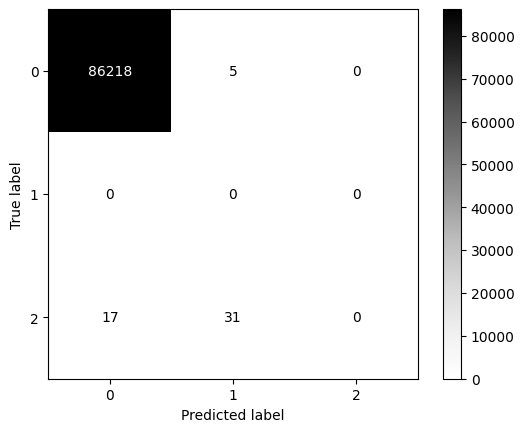

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = ConfusionMatrixDisplay.from_estimator(models[1], X_test, y_test,cmap='Greys')
#cm.plot(cmap='Greys')
plt.show()

In [ ]:
# https://www.geeksforgeeks.org/machine-learning/online-payment-fraud-detection-using-machine-learning-in-python/
# https://www.datacamp.com/courses/fraud-detection-in-python
# https://dev.to/agustin_bereciartua/building-a-fraud-detection-system-in-python-with-machine-learning-1p3n
# https://medium.com/@deolesopan/implementing-fraud-detection-in-python-identifying-suspicious-transactions-with-machine-learning-39c8cb3481f6
# https://thepythoncode.com/article/credit-card-fraud-detection-using-sklearn-in-python
# https://trenton3983.github.io/posts/fraud-detection-python/